# 🌟 Stellar Class — v6: Фокус на STAR (тюнинг порога решения)
**Kaggle Playground Series S6E6**

## Что выяснили из confusion matrix v5
Главная ошибка — **STAR → GALAXY: 11.1%**. Не GALAXY/QSO, как мы думали раньше.
STAR — самый малочисленный класс (14%), и его слабый recall (0.88) тянет
Balanced Accuracy вниз сильнее всего.

## Главная идея этого ноутбука
**Balanced Accuracy = среднее recall по классам. Precision её не волнует.**

Значит можно поднять recall STAR, домножив его вероятность на вес > 1
(понизить планку для предсказания STAR). Потеряем чуть-чуть precision STAR
и recall GALAXY — но из-за дисбаланса классов это выгодный обмен.

**Честное предупреждение:** это приём, эксплуатирующий структуру метрики.
Он легитимен и широко используется, но прирост зависит от того, насколько
ошибки «пограничные». Если модель ошибается уверенно — сдвиг порога не поможет.
Узнаем только запустив.

## 1. Импорты + данные + фичи (база из v2)

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FOLDS      = 5
PREV_BEST    = 0.93755   # лучший результат до этого (v2 / v5)

train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

def engineer_features(df):
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_z'] = df['g'] - df['z']
    df['g_i'] = df['g'] - df['i']
    df['r_z'] = df['r'] - df['z']
    df['u_i'] = df['u'] - df['i']
    df['r_g'] = df['r'] - df['g']
    df['i_g'] = df['i'] - df['g']
    df['z_r'] = df['z'] - df['r']
    df['log1p_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']    = df['redshift'] ** 2
    df['g_z_sq']         = df['g_z'] ** 2
    df['g_z_x_redshift'] = df['g_z'] * df['log1p_redshift']
    df['g_z_x_u_g']      = df['g_z'] * df['u_g']
    df['u_g_x_redshift'] = df['u_g'] * df['log1p_redshift']
    df['g_r_x_redshift'] = df['g_r'] * df['log1p_redshift']
    df['r_z_x_redshift'] = df['r_z'] * df['log1p_redshift']
    df['r_i_x_redshift'] = df['r_i'] * df['log1p_redshift']
    return df

train = engineer_features(train)
test  = engineer_features(test)

DROP_COLS    = ['id', 'class', 'alpha', 'delta', 'spectral_type', 'galaxy_population']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X      = train[FEATURE_COLS]
y      = train['class']
X_test = test[FEATURE_COLS]

le_target   = LabelEncoder()
y_encoded   = le_target.fit_transform(y)
CLASS_NAMES = list(le_target.classes_)   # ['GALAXY','QSO','STAR']
STAR_IDX    = CLASS_NAMES.index('STAR')

print(f'Фичей: {len(FEATURE_COLS)}')
print(f'Классы: {dict(zip(CLASS_NAMES, range(3)))}')
print(f'Индекс STAR: {STAR_IDX}')

Фичей: 28
Классы: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
Индекс STAR: 2


## 2. Обучаем одиночный LightGBM с OOF

Ансамбль не помог (v5), поэтому работаем с лучшей одиночной моделью —
LightGBM. Сохраняем OOF-вероятности: на них будем подбирать веса.

In [2]:
lgb_params = {
    'objective':         'multiclass',
    'num_class':         3,
    'metric':            'multi_logloss',
    'n_estimators':      1200,
    'learning_rate':     0.03,
    'num_leaves':        120,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
}

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_proba  = np.zeros((len(train), 3))
test_proba = np.zeros((len(test),  3))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[tr_idx], y_encoded[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

    oof_proba[val_idx] = model.predict_proba(X_val)
    test_proba        += model.predict_proba(X_test) / N_FOLDS
    s = balanced_accuracy_score(y_val, oof_proba[val_idx].argmax(1))
    print(f'Fold {fold+1} | BalAcc: {s:.5f}')

base_score = balanced_accuracy_score(y_encoded, oof_proba.argmax(1))
print(f'\nБазовый OOF (argmax): {base_score:.5f}')

Fold 1 | BalAcc: 0.93671
Fold 2 | BalAcc: 0.93762
Fold 3 | BalAcc: 0.93651
Fold 4 | BalAcc: 0.93785
Fold 5 | BalAcc: 0.93758

Базовый OOF (argmax): 0.93725


## 3. Базовая картина ошибок (argmax)

Смотрим per-class recall до тюнинга. Ожидаем STAR ~0.88.

In [3]:
y_base = oof_proba.argmax(1)
print('Per-class recall (argmax):')
cm = confusion_matrix(y_encoded, y_base)
recalls = cm.diagonal() / cm.sum(axis=1)
for name, rec in zip(CLASS_NAMES, recalls):
    print(f'  {name:7s}: {rec:.4f}')
print(f'\nBalanced Accuracy = среднее recall = {recalls.mean():.5f}')

Per-class recall (argmax):
  GALAXY : 0.9678
  QSO    : 0.9612
  STAR   : 0.8828

Balanced Accuracy = среднее recall = 0.93725


## 4. 🎯 Тюнинг весов классов

Вместо `argmax(proba)` делаем `argmax(proba × weights)`.

- `w_galaxy` фиксируем = 1.0 (точка отсчёта — умножение всех весов на константу
  ничего не меняет, поэтому свободны только 2 веса)
- `w_qso`, `w_star` перебираем
- Ищем комбинацию с максимальным Balanced Accuracy на OOF

Ждём что `w_star` уйдёт выше 1 — это поднимет recall STAR.

In [4]:
gal_idx = CLASS_NAMES.index('GALAXY')
qso_idx = CLASS_NAMES.index('QSO')

qso_grid  = np.arange(0.70, 1.41, 0.05)
star_grid = np.arange(0.80, 2.51, 0.05)

score_map = np.zeros((len(star_grid), len(qso_grid)))
best_score = 0
best_w     = np.array([1.0, 1.0, 1.0])

for si, w_star in enumerate(star_grid):
    for qi, w_qso in enumerate(qso_grid):
        w = np.ones(3)
        w[qso_idx]  = w_qso
        w[STAR_IDX] = w_star
        preds = (oof_proba * w).argmax(1)
        sc    = balanced_accuracy_score(y_encoded, preds)
        score_map[si, qi] = sc
        if sc > best_score:
            best_score = sc
            best_w     = w.copy()

print(f'Лучшие веса: GALAXY={best_w[gal_idx]:.2f}, QSO={best_w[qso_idx]:.2f}, STAR={best_w[STAR_IDX]:.2f}')
print(f'Balanced Accuracy после тюнинга: {best_score:.5f}')
print(f'Базовый (argmax):                {base_score:.5f}')
print(f'Прирост:                         {best_score - base_score:+.5f}', 
      '✅' if best_score > base_score else '❌')
print(f'Прирост vs прежний лучший:       {best_score - PREV_BEST:+.5f}')

Лучшие веса: GALAXY=1.00, QSO=1.40, STAR=2.50
Balanced Accuracy после тюнинга: 0.94795
Базовый (argmax):                0.93725
Прирост:                         +0.01069 ✅
Прирост vs прежний лучший:       +0.01040


## 5. Тепловая карта весов

Видим как Balanced Accuracy зависит от весов QSO и STAR.

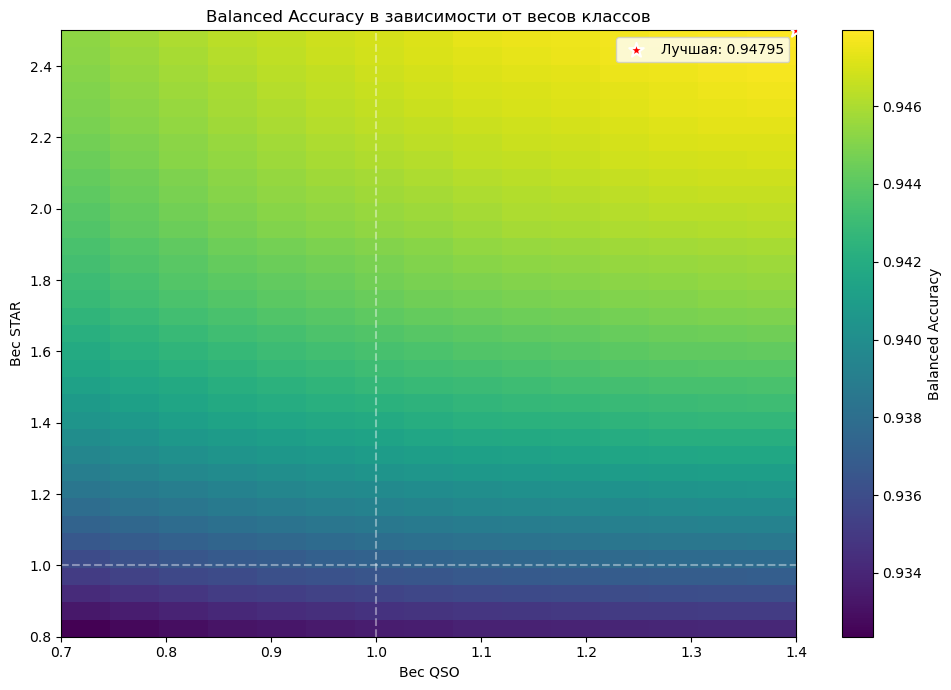

Белые пунктиры = веса (1,1), т.е. обычный argmax
Красная звезда = найденный оптимум


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(score_map, aspect='auto', origin='lower', cmap='viridis',
               extent=[qso_grid[0], qso_grid[-1], star_grid[0], star_grid[-1]])
ax.set_xlabel('Вес QSO')
ax.set_ylabel('Вес STAR')
ax.set_title('Balanced Accuracy в зависимости от весов классов')
# Отметим лучшую точку
ax.scatter(best_w[qso_idx], best_w[STAR_IDX], color='red', s=120, marker='*',
           edgecolor='white', linewidth=1.5, label=f'Лучшая: {best_score:.5f}', zorder=5)
ax.axhline(1.0, color='white', linestyle='--', alpha=0.4)
ax.axvline(1.0, color='white', linestyle='--', alpha=0.4)
ax.legend()
plt.colorbar(im, label='Balanced Accuracy')
plt.tight_layout()
plt.show()

print('Белые пунктиры = веса (1,1), т.е. обычный argmax')
print('Красная звезда = найденный оптимум')

## 6. Confusion Matrix: до и после тюнинга

Сравниваем напрямую — должен вырасти recall STAR.

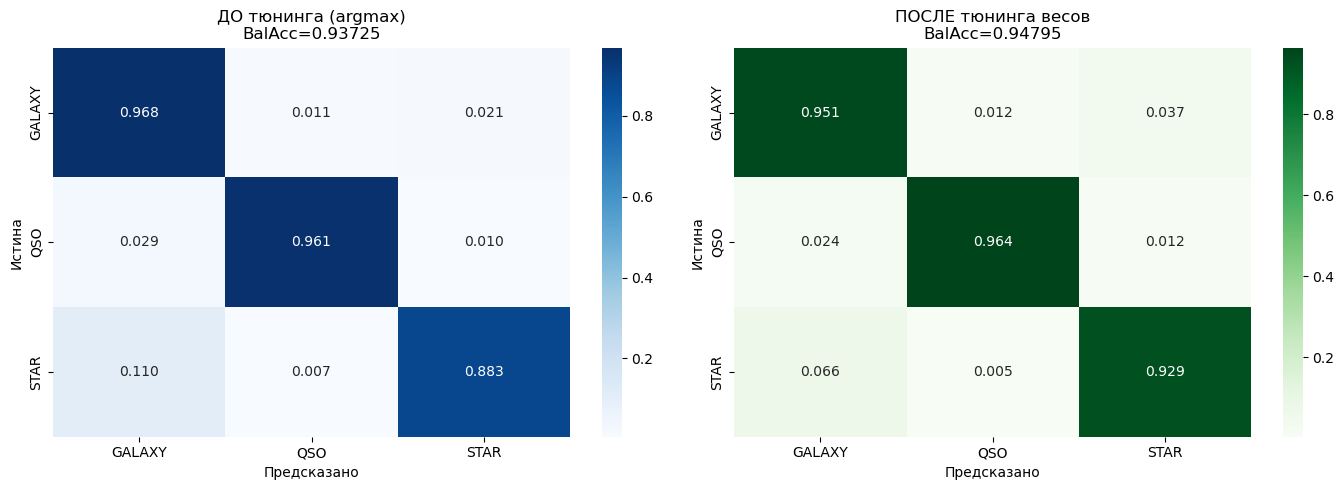

Изменение recall по классам:
  GALAXY : 0.9678 → 0.9507  (-0.0170)
  QSO    : 0.9612 → 0.9637  (+0.0025)
  STAR   : 0.8828 → 0.9295  (+0.0467)


In [6]:
y_tuned = (oof_proba * best_w).argmax(1)

cm_base  = confusion_matrix(y_encoded, y_base)
cm_tuned = confusion_matrix(y_encoded, y_tuned)
cm_base_n  = cm_base  / cm_base.sum(axis=1, keepdims=True)
cm_tuned_n = cm_tuned / cm_tuned.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_base_n, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'ДО тюнинга (argmax)\nBalAcc={base_score:.5f}')
axes[0].set_xlabel('Предсказано'); axes[0].set_ylabel('Истина')

sns.heatmap(cm_tuned_n, annot=True, fmt='.3f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'ПОСЛЕ тюнинга весов\nBalAcc={best_score:.5f}')
axes[1].set_xlabel('Предсказано'); axes[1].set_ylabel('Истина')
plt.tight_layout()
plt.show()

# Сравнение recall по классам
print('Изменение recall по классам:')
rec_base  = cm_base.diagonal()  / cm_base.sum(axis=1)
rec_tuned = cm_tuned.diagonal() / cm_tuned.sum(axis=1)
for name, rb, rt in zip(CLASS_NAMES, rec_base, rec_tuned):
    print(f'  {name:7s}: {rb:.4f} → {rt:.4f}  ({rt-rb:+.4f})')

## 7. Анализ ошибок: чем misclassified STAR отличаются?

Профилируем три группы по ключевым признакам:
- STAR, угаданные верно
- STAR, ошибочно названные GALAXY
- настоящие GALAXY

Если misclassified STAR по распределению ближе к GALAXY — значит они
физически в зоне перекрытия, и фичами их не вытащить (потолок данных).

STAR угаданы верно:          73030
STAR ошибочно → GALAXY:       9140
Всего GALAXY:               377480


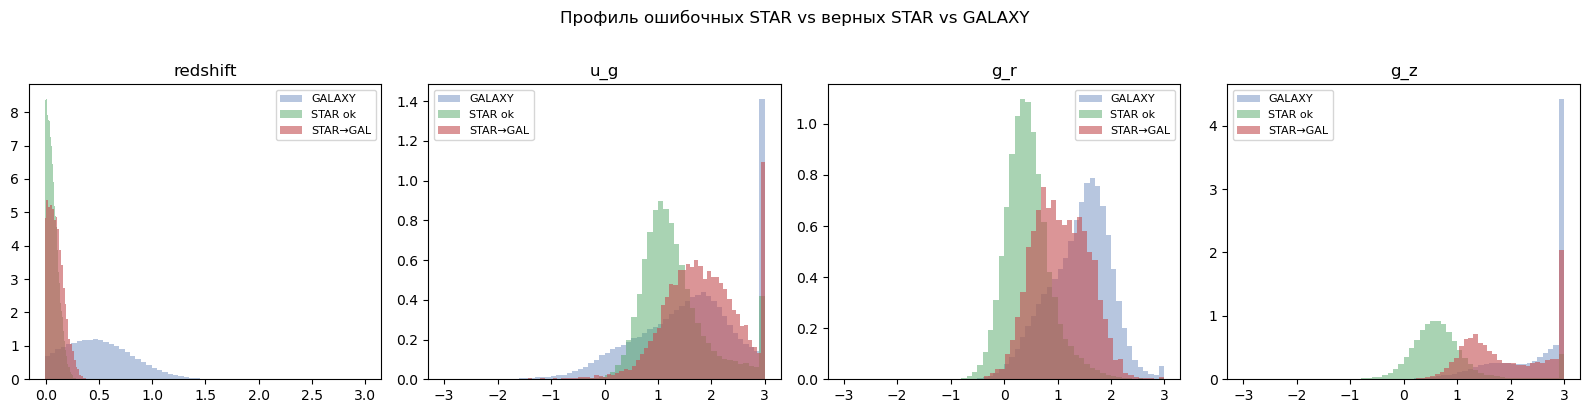

In [7]:
train_an = train.copy()
train_an['true']  = y_encoded
train_an['pred']  = y_base

gal, star = gal_idx, STAR_IDX
mask_star_ok    = (train_an['true']==star) & (train_an['pred']==star)
mask_star_wrong = (train_an['true']==star) & (train_an['pred']==gal)
mask_galaxy     = (train_an['true']==gal)

print(f'STAR угаданы верно:        {mask_star_ok.sum():>7d}')
print(f'STAR ошибочно → GALAXY:    {mask_star_wrong.sum():>7d}')
print(f'Всего GALAXY:              {mask_galaxy.sum():>7d}')

feats_to_check = ['redshift', 'u_g', 'g_r', 'g_z']
fig, axes = plt.subplots(1, len(feats_to_check), figsize=(16, 4))
for ax, f in zip(axes, feats_to_check):
    ax.hist(train_an.loc[mask_galaxy, f].clip(-3,3),     bins=60, alpha=0.4, density=True, label='GALAXY', color='#4C72B0')
    ax.hist(train_an.loc[mask_star_ok, f].clip(-3,3),    bins=60, alpha=0.5, density=True, label='STAR ok', color='#55A868')
    ax.hist(train_an.loc[mask_star_wrong, f].clip(-3,3), bins=60, alpha=0.6, density=True, label='STAR→GAL', color='#C44E52')
    ax.set_title(f)
    ax.legend(fontsize=8)
plt.suptitle('Профиль ошибочных STAR vs верных STAR vs GALAXY', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Сводка по redshift — ключевой признак
print('Медиана redshift по группам:')
print(f'  STAR верные:    {train_an.loc[mask_star_ok, "redshift"].median():.5f}')
print(f'  STAR ошибочные: {train_an.loc[mask_star_wrong, "redshift"].median():.5f}')
print(f'  GALAXY:         {train_an.loc[mask_galaxy, "redshift"].median():.5f}')
print('\nВывод смотрим: если у ошибочных STAR redshift как у GALAXY (заметно > 0),')
print('значит это "шумные" звёзды в зоне галактик — фичами почти не спасти.')

Медиана redshift по группам:
  STAR верные:    0.05326
  STAR ошибочные: 0.08814
  GALAXY:         0.48196

Вывод смотрим: если у ошибочных STAR redshift как у GALAXY (заметно > 0),
значит это "шумные" звёзды в зоне галактик — фичами почти не спасти.


## 8. Финальный сабмит с тюнингом весов

Применяем найденные веса к test-предсказаниям.

In [9]:
final_test_pred = (test_proba * best_w).argmax(1)
test_labels     = le_target.inverse_transform(final_test_pred)

submission = pd.DataFrame({'id': test['id'], 'class': test_labels})
submission.to_csv('../submissions/submission_v6_star_weights.csv', index=False)

print('Сабмит сохранён ✅')
print(f'Веса: GALAXY={best_w[gal_idx]:.2f}, QSO={best_w[qso_idx]:.2f}, STAR={best_w[STAR_IDX]:.2f}')
print('\nРаспределение предсказаний (сравни с argmax):')
print('  С тюнингом:')
print(submission['class'].value_counts().to_string())
print('\n  Без тюнинга (argmax) было бы:')
print(pd.Series(le_target.inverse_transform(test_proba.argmax(1))).value_counts().to_string())

Сабмит сохранён ✅
Веса: GALAXY=1.00, QSO=1.40, STAR=2.50

Распределение предсказаний (сравни с argmax):
  С тюнингом:
class
GALAXY    157517
QSO        50549
STAR       39369

  Без тюнинга (argmax) было бы:
GALAXY    162135
QSO        50274
STAR       35026


## 9. Итоговая таблица

In [10]:
print('='*62)
print(f'  Версия            │  CV/OOF    │  Что изменили')
print('─'*62)
print(f'  v1 baseline       │  0.93721   │  LightGBM из коробки')
print(f'  v2 features       │  0.93755   │  Feature engineering')
print(f'  v3 optuna         │  0.93735   │  Тюнинг (потолок одной модели)')
print(f'  v5 ensemble       │  0.93730   │  3 модели (не помогло)')
print(f'  v6 star weights   │  {best_score:.5f}   │  Тюнинг порога под Balanced Acc')
print('='*62)
print(f'\nПрирост v6 vs лучшего предыдущего: {best_score - PREV_BEST:+.5f}')
print('\n⚠️ Проверь на Kaggle LB — тюнинг весов должен перенестись,')
print('   т.к. распределение test то же (синтетика из одного источника).')

  Версия            │  CV/OOF    │  Что изменили
──────────────────────────────────────────────────────────────
  v1 baseline       │  0.93721   │  LightGBM из коробки
  v2 features       │  0.93755   │  Feature engineering
  v3 optuna         │  0.93735   │  Тюнинг (потолок одной модели)
  v5 ensemble       │  0.93730   │  3 модели (не помогло)
  v6 star weights   │  0.94795   │  Тюнинг порога под Balanced Acc

Прирост v6 vs лучшего предыдущего: +0.01040

⚠️ Проверь на Kaggle LB — тюнинг весов должен перенестись,
   т.к. распределение test то же (синтетика из одного источника).


## 10. Честный вывод

**Если прирост заметный (например +0.005 и больше):**
Отлично — мы нашли рычаг под метрику. Это правильный приём, переносим на LB.

**Если прирост маленький (< 0.002):**
Значит ошибки STAR не пограничные — модель ошибается уверенно, и это
потолок данных (см. анализ в секции 7: если ошибочные STAR по redshift
похожи на GALAXY, разделить их этими признаками невозможно).

В любом случае — это законченный, честный эксперимент. Мы проверили гипотезу
данными, а не догадками. Это и есть data science.